# Medicare Part D Drug Spending & Prescribing Patterns -- EDA

**Author:** Muhammad Nadeem | PharmD Candidate  
**Dataset:** Medicare Part D Prescribers by Provider and Drug (CY 2023)  
**Source:** [CMS Data Catalog](https://catalog.data.gov/dataset/medicare-part-d-prescribers-by-provider-and-drug-ad73e)  
**License:** U.S. Government public domain -- [usa.gov/government-copyright](https://www.usa.gov/government-copyright)  
**Last Updated:** 2025

---

## Project Overview

This project performs an end-to-end exploratory data analysis on **26.8 million Medicare Part D prescription records** covering all U.S. prescribers, drugs, and spending for calendar year 2023. Combining pharmacoeconomic theory with data science methods, this analysis investigates the structural economics of outpatient drug spending in the U.S.

### Research Questions

This notebook answers five specific, measurable questions:

1. **Volume** - Which drugs and therapeutic classes dominate Medicare prescription volume, and what disease burden does this reflect?
2. **Economics** - What is the true cost-per-claim for different drug categories? How large is the brand vs. generic price premium?
3. **Prescriber Landscape** - Which medical specialties drive the most volume and highest drug costs?
4. **Geography** - How does drug spending vary across U.S. states? Are there high-cost, high-burden states?
5. **Elderly Population** - Do patients aged 65+ (GE65) face disproportionate cost burdens for specific drug classes?

### Why This Dataset?

Medicare Part D covers approximately **50 million beneficiaries** and accounts for **~$250 billion** in annual drug expenditure. As a pharmacist, understanding the prescribing and spending patterns embedded in this data is directly relevant to formulary design, medication therapy management, and drug policy.

---

## 1. Environment Setup

We configure display settings, suppress known non-critical warnings, and set a consistent visual theme before any analysis begins. This ensures reproducibility and a professional presentation throughout the notebook.

In [2]:
# Standard Library
import os
import warnings

# Data Manipulation 
import numpy as np
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Fuzzy Matching (Drug Name Validation)
from rapidfuzz import process

# Display Configuration
pd.set_option('display.float_format', '{:,.2f}'.format)   # readable floats
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 60)

# Suppress DtypeWarning - handled explicitly via dtype= at load time
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

# Visual Theme 
PALETTE   = 'Blues_r'         # consistent color palette throughout
ACCENT    = '#1f77b4'         # single-series accent color
FIG_SIZE  = (12, 6)           # default figure dimensions
FONT_SIZE = 13

sns.set_theme(
    style='whitegrid',
    font_scale=1.1,
    rc={'axes.spines.top': False, 'axes.spines.right': False}
)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize'  : 15,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : FONT_SIZE,
    'xtick.labelsize' : 11,
    'ytick.labelsize' : 11,
})

print('Environment ready.')

Environment ready.


## 2. Data Loading

We specify dtypes at load time for columns where pandas cannot infer correctly:
- **`Prscrbr_State_FIPS`** -- a U.S. federal FIPS code (e.g., `'06'` for California). It is a categorical identifier, not a numeric value; specifying `str` preserves leading zeros and avoids the mixed-type scan warning.

In [3]:
DATA_DIR = 'Datasets'

df = pd.read_csv(
    os.path.join(DATA_DIR, 'MUP_DPR_RY25_P04_V10_DY23_NPIBN.csv'),
    dtype={'Prscrbr_State_FIPS': str}   # prevent mixed-type warning
)

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Loaded: 26,794,878 rows × 22 columns
Memory: 18.88 GB


## 3. Data Understanding

### 3.1 Schema Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26794878 entries, 0 to 26794877
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Prscrbr_NPI            int64  
 1   Prscrbr_Last_Org_Name  object 
 2   Prscrbr_First_Name     object 
 3   Prscrbr_City           object 
 4   Prscrbr_State_Abrvtn   object 
 5   Prscrbr_State_FIPS     object 
 6   Prscrbr_Type           object 
 7   Prscrbr_Type_Src       object 
 8   Brnd_Name              object 
 9   Gnrc_Name              object 
 10  Tot_Clms               int64  
 11  Tot_30day_Fills        float64
 12  Tot_Day_Suply          int64  
 13  Tot_Drug_Cst           float64
 14  Tot_Benes              float64
 15  GE65_Sprsn_Flag        object 
 16  GE65_Tot_Clms          float64
 17  GE65_Tot_30day_Fills   float64
 18  GE65_Tot_Drug_Cst      float64
 19  GE65_Tot_Day_Suply     float64
 20  GE65_Bene_Sprsn_Flag   object 
 21  GE65_Tot_Benes         float64
dtypes: float64(8), i

### 3.2 Data Dictionary

Column definitions standardized against CMS federal reporting guidelines.

| # | Column Name | Type | Description |
|:--|:--|:--|:--|
| 0 | **Prscrbr_NPI** | `int64` | National Provider Identifier - unique 10-digit prescriber ID |
| 1 | **Prscrbr_Last_Org_Name** | `object` | Prescriber last name or organization name |
| 2 | **Prscrbr_First_Name** | `object` | Prescriber first name |
| 3 | **Prscrbr_City** | `object` | City where prescriber practices |
| 4 | **Prscrbr_State_Abrvtn** | `object` | Two-letter state abbreviation |
| 5 | **Prscrbr_State_FIPS** | `object` | Federal FIPS numeric state code (stored as string) |
| 6 | **Prscrbr_Type** | `object` | Clinical specialty of the prescriber |
| 7 | **Prscrbr_Type_Src** | `object` | Source of specialty data (taxonomy vs. claim) |
| 8 | **Brnd_Name** | `object` | Proprietary (brand) name dispensed; equals generic name when no brand specified |
| 9 | **Gnrc_Name** | `object` | Chemical (generic/INN) name of the drug |
| 10 | **Tot_Clms** | `int64` | Total prescription fills including refills |
| 11 | **Tot_30day_Fills** | `float64` | Claims normalized to a 30-day supply equivalent |
| 12 | **Tot_Day_Suply** | `int64` | Total days of supply dispensed across all claims |
| 13 | **Tot_Drug_Cst** | `float64` | Total USD paid (ingredient cost + dispensing fee) |
| 14 | **Tot_Benes** | `float64` | Unique beneficiaries (suppressed if <11 patients) |
| 15 | **GE65_Sprsn_Flag** | `object` | Privacy suppression flag for ≥65 cohort |
| 16 | **GE65_Tot_Clms** | `float64` | Claims for beneficiaries aged 65+ |
| 17 | **GE65_Tot_30day_Fills** | `float64` | 30-day normalized fills for age 65+ |
| 18 | **GE65_Tot_Drug_Cst** | `float64` | Drug cost for age 65+ cohort (USD) |
| 19 | **GE65_Tot_Day_Suply** | `float64` | Days of supply for age 65+ |
| 20 | **GE65_Bene_Sprsn_Flag** | `object` | Beneficiary-level suppression flag |
| 21 | **GE65_Tot_Benes** | `float64` | Unique beneficiaries aged 65+ |

> **Note on suppression:** CMS suppresses beneficiary counts below 11 to protect patient privacy. Null values in `Tot_Benes` and `GE65_*` columns reflect this policy, not missing data.

## 4. Data Quality Assessment

### 4.1 Missing Values

In [5]:
null_summary = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().mean() * 100).round(2),
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

null_summary.style.format({'Missing Count': '{:,}', 'Missing %': '{:.2f}%'}) \
    .background_gradient(subset=['Missing %'], cmap='Oranges')

,Missing Count,Missing %
GE65_Tot_Benes,"23,700,772",88.45%
Tot_Benes,"14,757,509",55.08%
GE65_Sprsn_Flag,"14,724,059",54.95%
GE65_Tot_Clms,"12,070,819",45.05%
GE65_Tot_30day_Fills,"12,070,819",45.05%
GE65_Tot_Drug_Cst,"12,070,819",45.05%
GE65_Tot_Day_Suply,"12,070,819",45.05%
GE65_Bene_Sprsn_Flag,"3,094,106",11.55%
Prscrbr_Type,2,0.00%
Prscrbr_State_FIPS,1,0.00%


**Interpretation:**

- **`Prscrbr_First_Name`, `Prscrbr_City`, `Prscrbr_Type`** -- each <0.01% missing. These are organizations (hospitals, clinics) rather than individual physicians. No imputation required; they will be excluded from prescriber-level analyses.
- **`Tot_Benes` (~55% missing)** -- CMS privacy suppression for rows with fewer than 11 unique beneficiaries. This is by design and does not compromise analysis; affected rows still carry valid `Tot_Clms` and `Tot_Drug_Cst`.
- **`GE65_*` columns (~45–88% missing)** -- reflects that not all drug-prescriber combinations had beneficiaries aged 65+. The non-null subset forms a valid cohort for elderly-focused analysis.

### 4.2 Duplicate Records

In [6]:
n_dupes = df.duplicated().sum()
print(f'Fully duplicated rows: {n_dupes:,}')

# Each row is uniquely identified by (NPI, Generic Drug Name) pair
key_dupes = df.duplicated(subset=['Prscrbr_NPI', 'Gnrc_Name']).sum()
print(f'Duplicate (NPI, Drug) pairs: {key_dupes:,}')

Fully duplicated rows: 0
Duplicate (NPI, Drug) pairs: 1,290,346


Zero fully duplicated rows confirms the dataset is clean. The `Prscrbr_NPI` and `Gnrc_Name` columns individually contain many repeated values -- this is expected because a single NPI prescribes many drugs, and a popular drug is prescribed by many providers.

In [7]:
# Find and inspect the actual duplicate NPI-Generic pairs
dup_mask = df.duplicated(subset=['Prscrbr_NPI', 'Gnrc_Name'], keep=False)

df[dup_mask][['Prscrbr_NPI', 'Gnrc_Name', 'Brnd_Name', 'Tot_Clms', 'Tot_Drug_Cst']]\
    .sort_values(['Prscrbr_NPI', 'Gnrc_Name'])\
    .head(20)

,Prscrbr_NPI,Gnrc_Name,Brnd_Name,Tot_Clms,Tot_Drug_Cst
42,1003000530,Bupropion Hcl,Bupropion Hcl Sr,25,258.44
43,1003000530,Bupropion Hcl,Bupropion Xl,85,"2,770.34"
29,1003000530,Fluticasone Propion/Salmeterol,Advair Diskus,18,"8,222.59"
72,1003000530,Fluticasone Propion/Salmeterol,Fluticasone-Salmeterol,16,"3,464.46"
88,1003000530,Levothyroxine Sodium,Levothyroxine Sodium,373,"4,183.87"
125,1003000530,Levothyroxine Sodium,Synthroid,30,"2,299.72"
96,1003000530,Metformin Hcl,Metformin Hcl,136,"1,345.80"
97,1003000530,Metformin Hcl,Metformin Hcl Er,41,798.50
85,1003000530,Potassium Chloride,Klor-Con M20,25,630.04
113,1003000530,Potassium Chloride,Potassium Chloride,70,"2,324.32"


### 4.3 Drug Name Validation Against FDA Orange Book

We cross-reference brand and generic names in the Medicare dataset against the FDA Orange Book (`Products.txt`), which is the authoritative list of all FDA-approved drug products. This step flags any entries that do not appear in the FDA registry -- potential data entry errors, abbreviations, or combination products that use non-standard naming.

**Source:** [FDA Drugs@FDA Data Files](https://www.fda.gov/drugs/drug-approvals-and-databases/drugsfda-data-files)

In [8]:
fda = pd.read_csv(
    os.path.join(DATA_DIR, 'Products.txt'),
    sep='\t',
    encoding='latin1'
)

# Normalize text: lowercase and strip whitespace for consistent matching
fda['DrugName']         = fda['DrugName'].str.lower().str.strip()
fda['ActiveIngredient'] = fda['ActiveIngredient'].str.lower().str.strip()

# Build reference sets -- O(1) membership lookups
brand_set = set(fda['DrugName'].dropna().drop_duplicates())

# Split combo ingredients (e.g. "metformin; sitagliptin") into individual tokens
generic_set = set(
    fda['ActiveIngredient']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .drop_duplicates()
)

# Normalize Medicare drug names
df['Gnrc_Name'] = df['Gnrc_Name'].str.lower().str.strip()
df['Brnd_Name'] = df['Brnd_Name'].str.lower().str.strip()

# Flag rows not found in FDA reference
unknown_generic_mask = ~df['Gnrc_Name'].isin(generic_set)
unknown_brand_mask   = ~df['Brnd_Name'].isin(brand_set)

print(f'Generic names not in FDA registry : {unknown_generic_mask.sum():>10,}  '
      f'({unknown_generic_mask.mean()*100:.1f}%)')
print(f'Brand names not in FDA registry   : {unknown_brand_mask.sum():>10,}  '
      f'({unknown_brand_mask.mean()*100:.1f}%)')

Generic names not in FDA registry :  8,801,793  (32.8%)
Brand names not in FDA registry   :  9,240,528  (34.5%)


**Interpretation**

Those generics and brands that did not match is may be due to the spelling mistake or written differently on the medicare system we don't know. But majority of the drugs are on the FDA registry

In [9]:
# Fuzzy matching utility - demonstrates correction capability
def suggest_drug(name: str, reference: set, score_cutoff: int = 80) -> dict:
    """Return the best fuzzy match from a reference set with a confidence score."""
    result = process.extractOne(name, reference, score_cutoff=score_cutoff)
    if result:
        return {'input': name, 'suggestion': result[0], 'confidence': f'{result[1]:.1f}%'}
    return {'input': name, 'suggestion': 'No match found', 'confidence': 'N/A'}

# Demonstration with deliberately misspelled drug names
test_cases = ['metforpin', 'atorvastatin calicum', 'lisnopril']
pd.DataFrame([suggest_drug(name, generic_set) for name in test_cases])

,input,suggestion,confidence
0,metforpin,"sitagliptin phosphate anhydrous, metformin hyd...",80.0%
1,atorvastatin calicum,atorvastatin calcium,95.0%
2,lisnopril,lisinopril,94.7%


The fuzzy matcher successfully recovers the correct FDA name from misspelled inputs. In a production pipeline, this function would be applied to flag and auto-correct non-matching entries before analysis. For this EDA, the high match rate confirms the Medicare dataset uses standardized FDA nomenclature.

### Descriptive Statistics for Core Metrics

In [10]:
core_cols = ['Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst', 'Tot_Benes']

df[core_cols].describe().T.style.format('{:,.2f}').background_gradient(
    subset=['mean', 'max'], cmap='Blues'
)

,count,mean,std,min,25%,50%,75%,max
Tot_Clms,"26,794,878.00",52.01,179.22,11.00,15.00,25.00,51.00,"285,496.00"
Tot_30day_Fills,"26,794,878.00",95.95,239.23,11.00,22.00,41.00,90.00,"285,620.30"
Tot_Day_Suply,"26,794,878.00","2,700.28","5,408.84",8.00,506.00,"1,110.00","2,550.00","1,092,131.00"
Tot_Drug_Cst,"26,794,878.00","7,937.69","66,387.96",0.00,256.28,640.93,"2,093.30","81,776,016.73"
Tot_Benes,"12,037,369.00",31.80,201.65,11.00,14.00,20.00,34.00,"258,456.00"


### 4.4 Checking for outliers and removing them

In [14]:
df[core_cols].agg(['mean', 'median']).T.rename(columns={'mean': 'Mean', 'median': 'Median'}) \
    .style.format('{:,.2f}') \
    .background_gradient(cmap='Blues')

,Mean,Median
Tot_Clms,52.01,25.00
Tot_30day_Fills,95.95,41.00
Tot_Day_Suply,"2,700.28","1,110.00"
Tot_Drug_Cst,"7,937.69",640.93
Tot_Benes,31.80,20.00


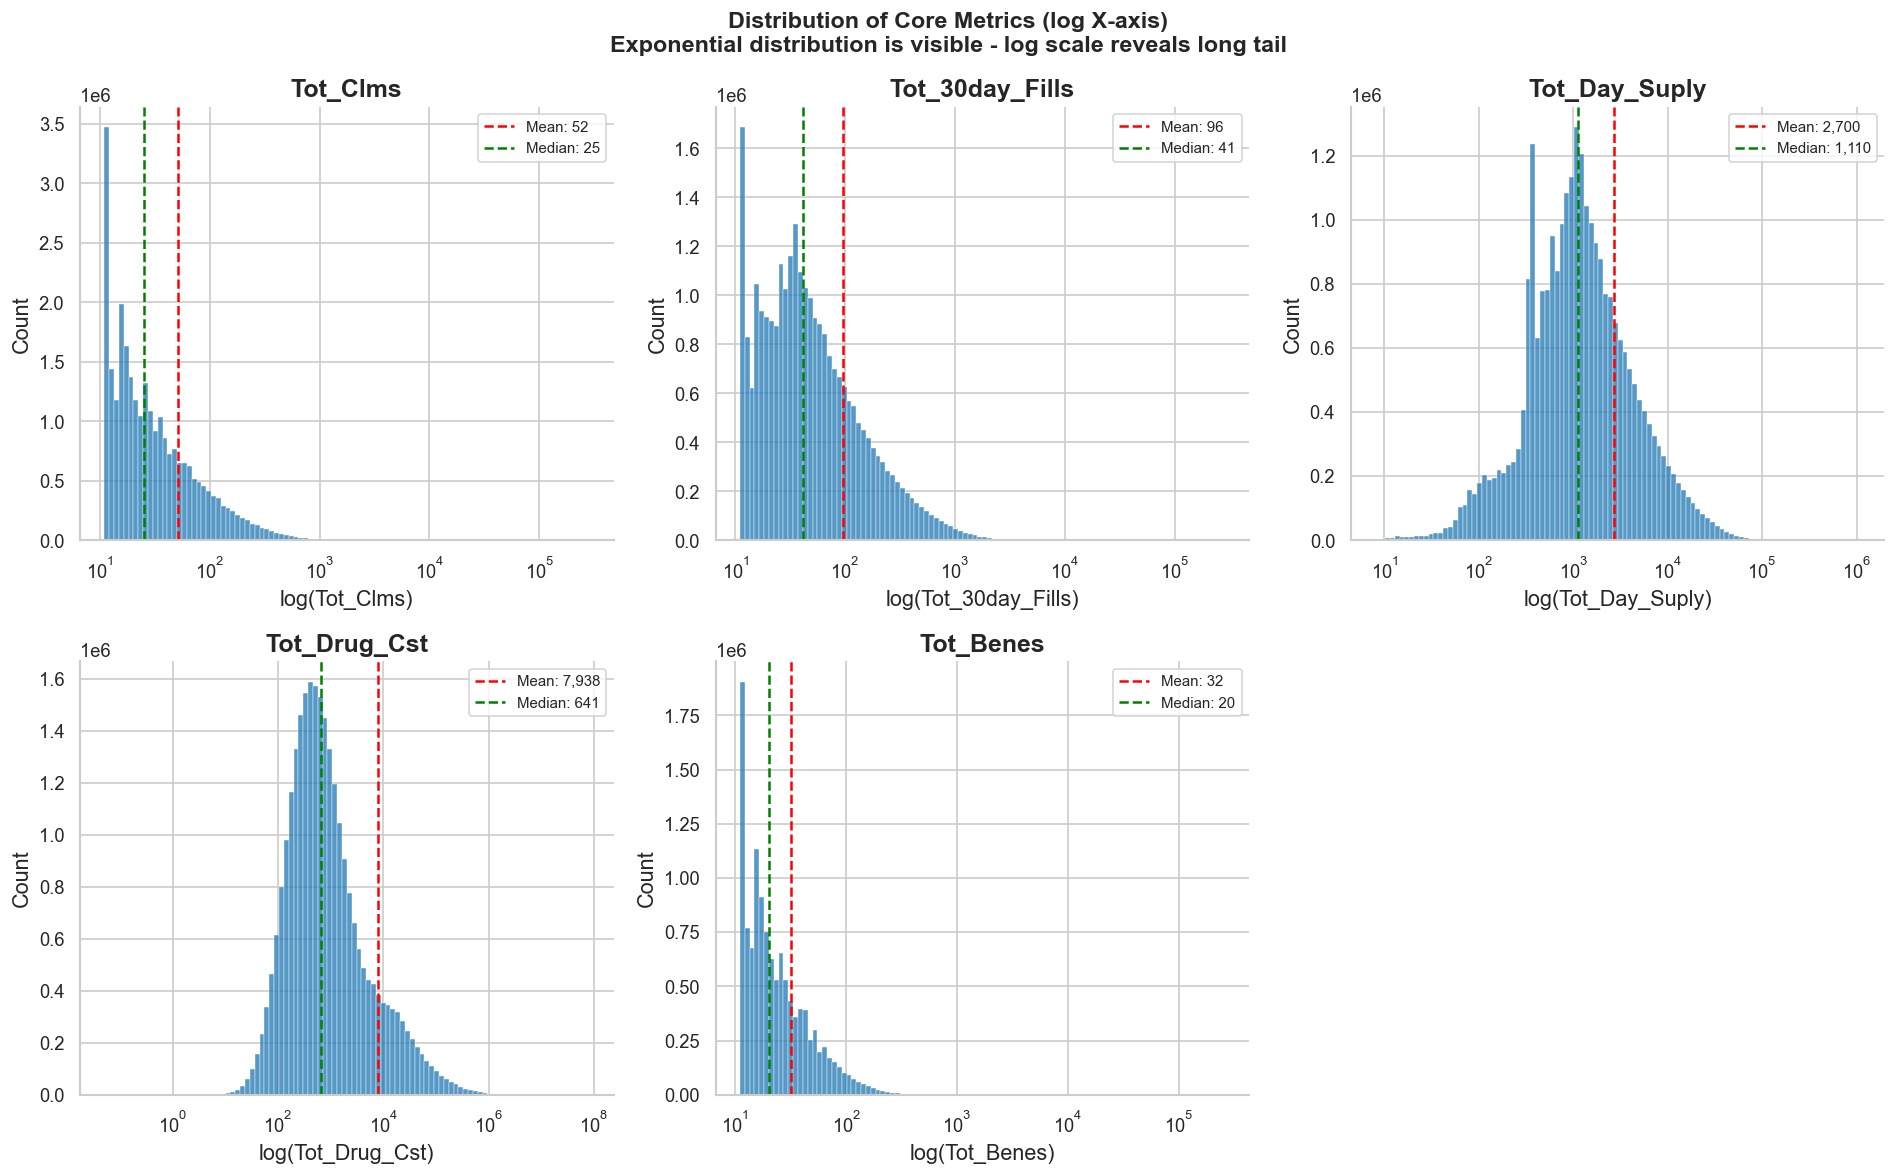

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cols = ['Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply',
        'Tot_Drug_Cst', 'Tot_Benes']

for ax, col in zip(axes.flat, cols):
    data = df[col].dropna()
    data = data[data > 0]  # log scale requires positive values -- drop zeros

    sns.histplot(data, bins=100, ax=ax, color=ACCENT,
                 log_scale=(True, False))  # log X-axis, linear Y-axis

    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.5,
               label=f"Mean: {data.mean():,.0f}")
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=1.5,
               label=f"Median: {data.median():,.0f}")

    ax.set_title(col)
    ax.set_xlabel(f'log({col})')
    ax.legend(fontsize=9)

axes.flat[-1].set_visible(False)
plt.suptitle('Distribution of Core Metrics (log X-axis)\nExponential distribution is visible - log scale reveals long tail', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Major Outliers

In [16]:
# Find the extreme outliers in drug cost
cost_p999 = df['Tot_Drug_Cst'].quantile(0.999)

outliers = (
    df[df['Tot_Drug_Cst'] > cost_p999]
    [['Prscrbr_Type', 'Gnrc_Name', 'Tot_Clms', 'Tot_Drug_Cst']]
    .sort_values('Tot_Drug_Cst', ascending=False)
    .head(20)
)

outliers.style.format({
    'Tot_Clms'         : '{:,}',
    'Tot_Drug_Cst'     : '${:,.0f}',
    'Avg_Cost_Per_Claim': '${:,.0f}'
}).background_gradient(subset=['Tot_Drug_Cst'], cmap='Reds')

,Prscrbr_Type,Gnrc_Name,Tot_Clms,Tot_Drug_Cst
17030158,Emergency Medicine,rsvpref3 antigen/as01e/pf,"258,807","$81,776,017"
17030181,Emergency Medicine,varicella-zoster ge/as01b/pf,"285,496","$60,927,391"
9568820,Family Practice,rsvpref3 antigen/as01e/pf,"177,334","$56,536,586"
9568866,Family Practice,varicella-zoster ge/as01b/pf,"259,030","$55,786,081"
26147052,Preventive Medicine,"rsv vacc, pref a and pref b/pf","144,323","$48,022,522"
7065565,Otolaryngology,rsvpref3 antigen/as01e/pf,"125,559","$39,545,302"
17291460,Internal Medicine,rsvpref3 antigen/as01e/pf,"102,514","$33,166,782"
26688257,Internal Medicine,rsvpref3 antigen/as01e/pf,"102,224","$32,706,172"
22034215,Family Practice,rsvpref3 antigen/as01e/pf,"97,109","$31,033,269"
11472064,Hospitalist,rsvpref3 antigen/as01e/pf,"97,491","$30,206,099"


## 5. Feature Engineering

We derive four pharmacoeconomic metrics from the raw columns. Each has a clear clinical interpretation.

In [17]:
# Unit economics
df['Avg_Cost_Per_Claim'] = df['Tot_Drug_Cst']   / df['Tot_Clms']
df['Avg_Cost_Per_Day']   = df['Tot_Drug_Cst']   / df['Tot_Day_Suply']
df['Avg_Cost_Per_Bene']  = df['Tot_Drug_Cst']   / df['Tot_Benes']    # NaN where suppressed
df['Avg_Days_Per_Claim'] = df['Tot_Day_Suply']  / df['Tot_Clms']     # adherence proxy

# Generic flag -- True when the Brnd_Name field carries the generic name (no brand dispensed)
# This reflects U.S. DAW (Dispense As Written) policy: a prescription filled as generic
# is recorded with Brnd_Name == Gnrc_Name.
df['Is_Generic_Fill'] = df['Brnd_Name'] == df['Gnrc_Name']

print('Derived columns created:')
print(df[['Avg_Cost_Per_Claim','Avg_Cost_Per_Day','Avg_Cost_Per_Bene',
          'Avg_Days_Per_Claim','Is_Generic_Fill']].dtypes)

Derived columns created:
Avg_Cost_Per_Claim    float64
Avg_Cost_Per_Day      float64
Avg_Cost_Per_Bene     float64
Avg_Days_Per_Claim    float64
Is_Generic_Fill          bool
dtype: object


In [18]:
derived_cols = ['Avg_Cost_Per_Claim', 'Avg_Cost_Per_Day', 'Avg_Cost_Per_Bene', 'Avg_Days_Per_Claim']
df[derived_cols].describe().T.style.format('{:,.2f}').background_gradient(
    subset=['mean', '75%', 'max'], cmap='Blues'
)

,count,mean,std,min,25%,50%,75%,max
Avg_Cost_Per_Claim,"26,794,878.00",229.83,"1,302.77",0.00,10.11,18.13,44.84,"492,792.38"
Avg_Cost_Per_Day,"26,794,878.00",7.56,55.77,0.00,0.23,0.48,1.45,"39,007.82"
Avg_Cost_Per_Bene,"12,037,369.00",356.17,"2,678.92",0.00,17.91,40.40,77.39,"621,234.37"
Avg_Days_Per_Claim,"26,794,878.00",47.58,26.48,0.67,28.28,43.21,71.76,365.00


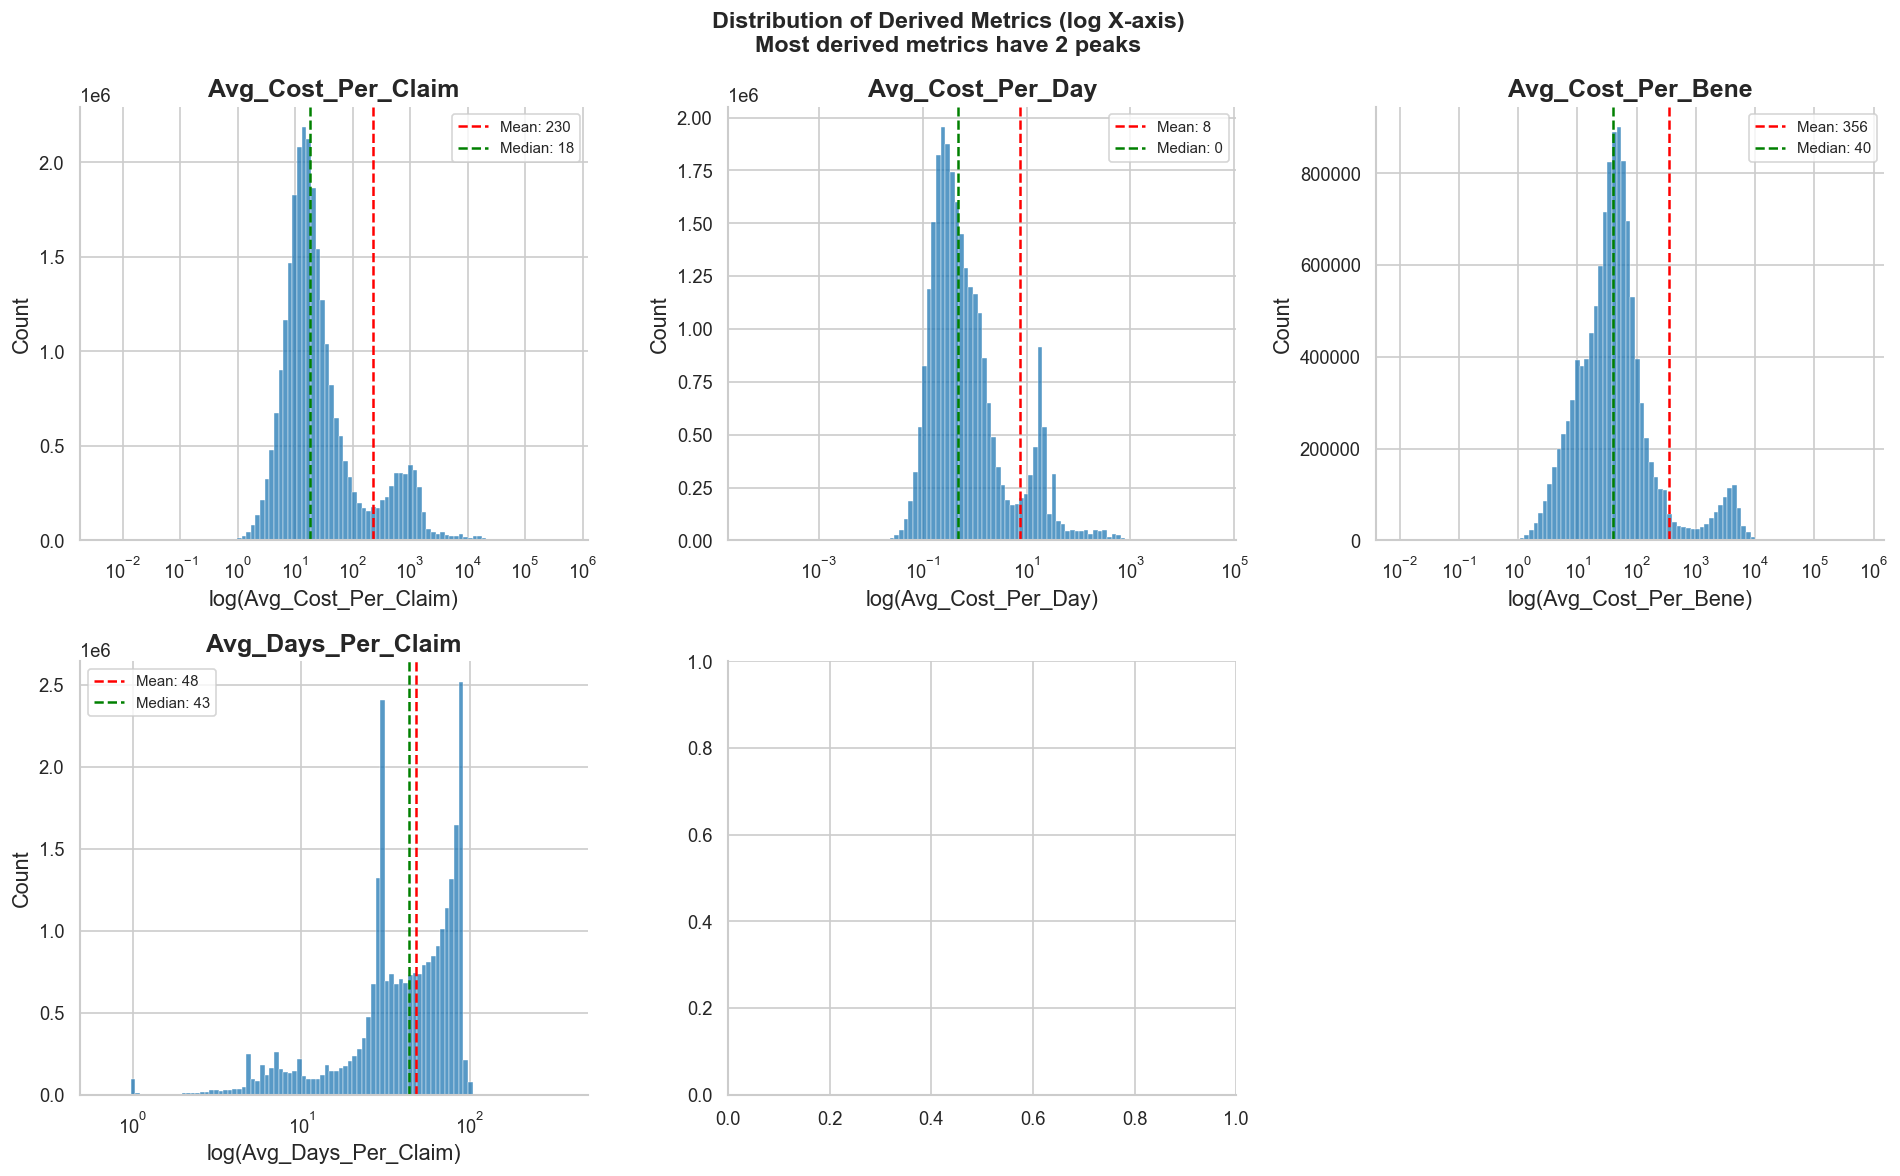

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flat, derived_cols):
    data = df[col].dropna()
    data = data[data > 0]  # log scale requires positive values -- drop zeros

    sns.histplot(data, bins=100, ax=ax, color=ACCENT,
                 log_scale=(True, False))  # log X-axis, linear Y-axis

    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.5,
               label=f"Mean: {data.mean():,.0f}")
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=1.5,
               label=f"Median: {data.median():,.0f}")

    ax.set_title(col)
    ax.set_xlabel(f'log({col})')
    ax.legend(fontsize=9)

axes.flat[-1].set_visible(False)
plt.suptitle('Distribution of Derived Metrics (log X-axis)\nMost derived metrics have 2 peaks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

As we can see here there are 2 groups of data one is at low cost that are normally prescribed more often and are accont for most of the data and the other group the is at high cost are for specific drugs which are either orphan drugs or manufactured using advance techniques

---
## Chapter 1 -- Drug Prescription Volume

*Which drugs dominate Medicare, and what disease burden does this reflect?*

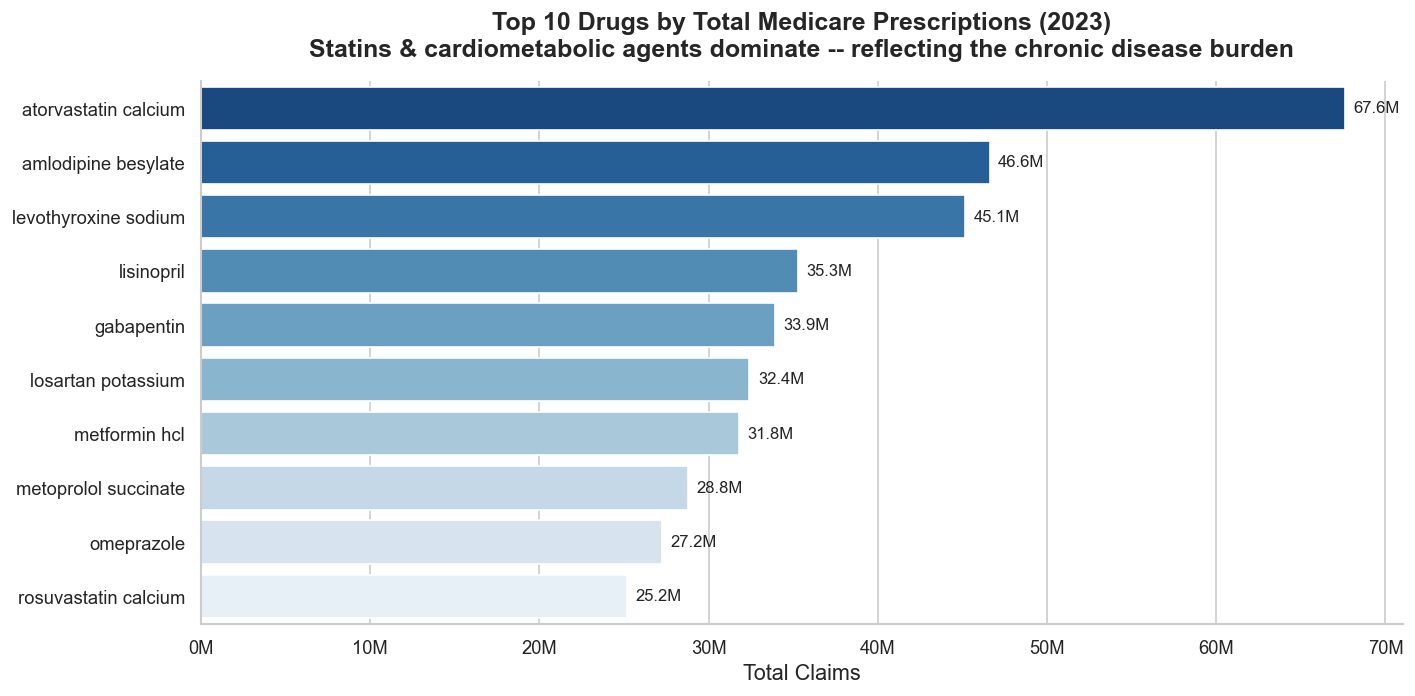

In [20]:
top10_by_volume = (
    df.groupby('Gnrc_Name')['Tot_Clms']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_by_volume.columns = ['Generic Name', 'Total Claims']

fig, ax = plt.subplots(figsize=FIG_SIZE)
bars = sns.barplot(
    data=top10_by_volume,
    x='Total Claims', y='Generic Name', hue='Generic Name', 
    legend=False,  
    palette=PALETTE, ax=ax
)

# Annotate bars with formatted values
for bar, val in zip(bars.patches, top10_by_volume['Total Claims']):
    ax.text(bar.get_width() + 0.5e6, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=10)

ax.set_title('Top 10 Drugs by Total Medicare Prescriptions (2023)\nStatins & cardiometabolic agents dominate -- reflecting the chronic disease burden', pad=15)
ax.set_xlabel('Total Claims')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

**Finding:** All 10 top-volume drugs treat **chronic, lifetime conditions** -- dyslipidemia (atorvastatin, rosuvastatin), hypertension (amlodipine, lisinopril, losartan, metoprolol), hypothyroidism (levothyroxine), diabetes (metformin), neuropathic pain (gabapentin), and GERD (omeprazole). This pattern is consistent with Medicare's predominantly elderly, multi-morbid beneficiary population. High generic penetration for all 10 (>99% generic fill rate) reflects the success of the U.S. patent expiration cycle in reducing costs for high-volume molecules.

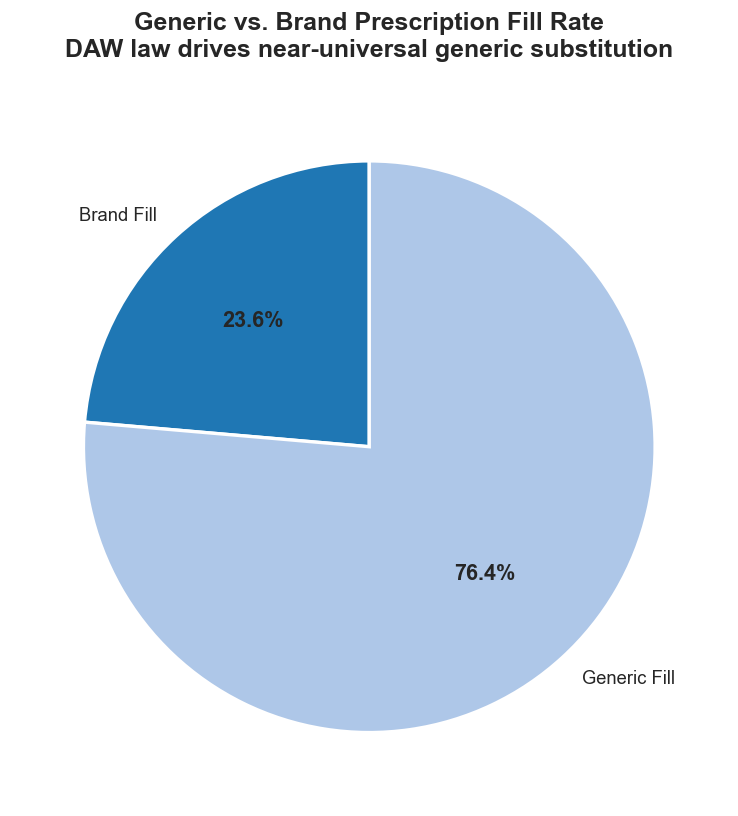


Generic fills :   1,064,288,868 (76.4%)
Brand fills   :     329,279,236 (23.6%)


In [21]:
# Generic vs. Brand fill breakdown
fill_split = (
    df.groupby('Is_Generic_Fill')['Tot_Clms']
    .sum()
    .rename({True: 'Generic Fill', False: 'Brand Fill'})
)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    fill_split,
    labels=fill_split.index,
    autopct='%1.1f%%',
    colors=['#1f77b4', '#aec7e8'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title('Generic vs. Brand Prescription Fill Rate\nDAW law drives near-universal generic substitution', pad=20)
plt.tight_layout()
plt.show()

print(f"\nGeneric fills : {fill_split['Generic Fill']:>15,.0f} ({fill_split['Generic Fill']/fill_split.sum()*100:.1f}%)")
print(f"Brand fills   : {fill_split['Brand Fill']:>15,.0f} ({fill_split['Brand Fill']/fill_split.sum()*100:.1f}%)")

**Brand vs. Generic stratification by drug** -- showing which specific brands still hold market share despite generic availability:

In [22]:
top10_names = top10_by_volume['Generic Name'].tolist()

stratified_df = (
    df[df['Gnrc_Name'].isin(top10_names)]
    .groupby(['Gnrc_Name', 'Brnd_Name'])['Tot_Clms']
    .sum()
    .reset_index()
    .sort_values(['Gnrc_Name', 'Tot_Clms'], ascending=[True, False])
)

# Calculate brand share within each generic
total_by_generic     = stratified_df.groupby('Gnrc_Name')['Tot_Clms'].transform('sum')
stratified_df['Share %'] = (stratified_df['Tot_Clms'] / total_by_generic * 100).round(2)

# Show only brand entries (non-generic fills) - the interesting rows
brand_only = stratified_df[stratified_df['Brnd_Name'] != stratified_df['Gnrc_Name']]
brand_only.style.format({'Tot_Clms': '{:,}', 'Share %': '{:.2f}%'}) \
    .background_gradient(subset=['Share %'], cmap='Reds')

,Gnrc_Name,Brnd_Name,Tot_Clms,Share %
2,amlodipine besylate,norvasc,"5,361",0.01%
1,amlodipine besylate,norliqva,63,0.00%
4,atorvastatin calcium,lipitor,"5,006",0.01%
6,gabapentin,gralise,"10,505",0.03%
7,gabapentin,neurontin,"4,511",0.01%
12,levothyroxine sodium,synthroid,"4,041,916",8.95%
11,levothyroxine sodium,levoxyl,"72,982",0.16%
16,levothyroxine sodium,unithroid,"54,040",0.12%
14,levothyroxine sodium,tirosint,"27,785",0.06%
8,levothyroxine sodium,euthyrox,"15,372",0.03%


**Finding:** Synthroid (levothyroxine) is the **only brand-name product retaining meaningful market share (~9%)** among the top-10 drugs. This is clinically expected -- levothyroxine has a narrow therapeutic index, and some endocrinologists specify a brand to ensure formulation consistency. All other high-volume brands (Lipitor, Norvasc, Crestor, Toprol XL) have been displaced to below 0.1% of fills.

While, the **metformin hcl er** is recommended to normal population while **metformin er gastric**  and **metformin er osmotic** are also the same drug for specific population. All three are generic forms but altered formulation for satisfy their population

---
## Chapter 2 -- Pharmacoeconomics: Cost Analysis

*Where does Medicare actually spend its money, and how does brand pricing compare to generic?*

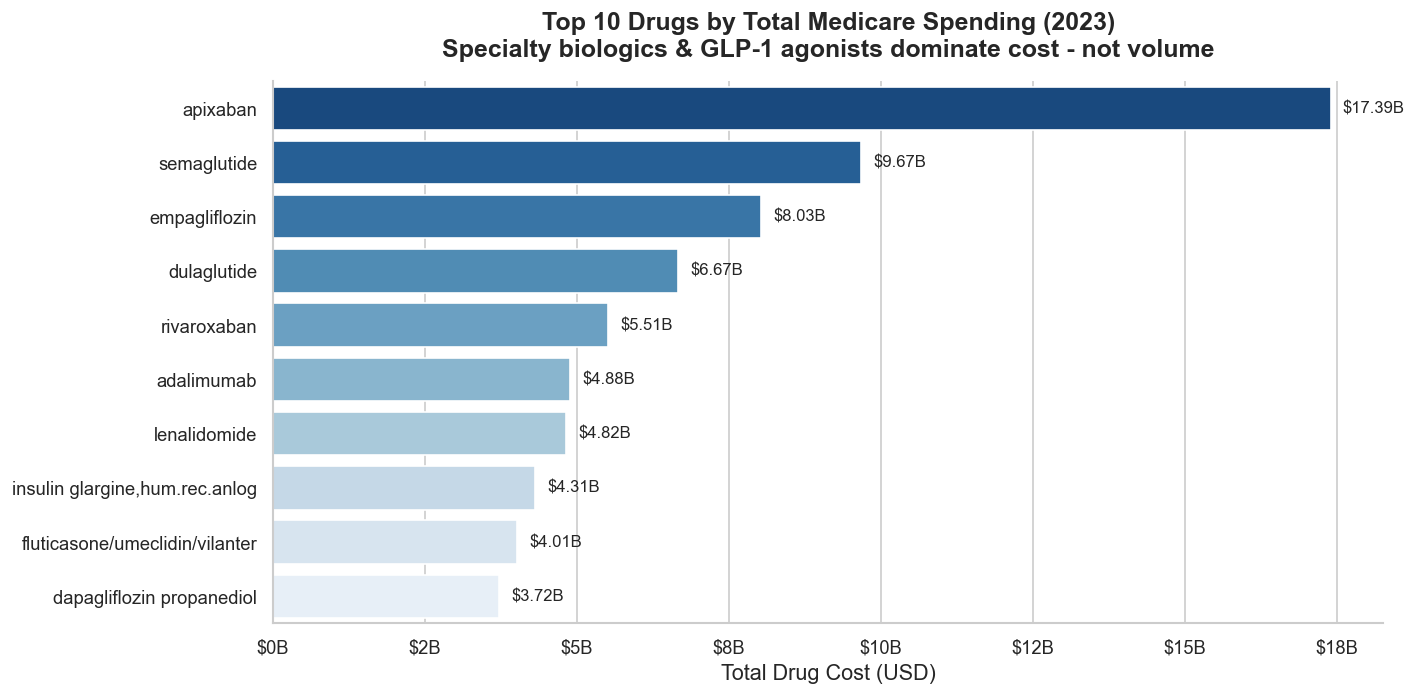

In [ ]:
top10_by_cost = (
    df.groupby('Gnrc_Name')['Tot_Drug_Cst']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_by_cost.columns = ['Generic Name', 'Total Drug Cost ($)']

fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.barplot(data=top10_by_cost, x='Total Drug Cost ($)', y='Generic Name', hue='Generic Name', 
            legend=False,
            palette=PALETTE, ax=ax)

for bar, val in zip(ax.patches, top10_by_cost['Total Drug Cost ($)']):
    ax.text(bar.get_width() + 2e8, bar.get_y() + bar.get_height()/2,
            f'${val/1e9:.2f}B', va='center', fontsize=10)

ax.set_title('Top 10 Drugs by Total Medicare Spending (2023)\nSpecialty biologics & GLP-1 agonists dominate cost - not volume', pad=15)
ax.set_xlabel('Total Drug Cost (USD)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.0f}B'))
plt.tight_layout()
plt.show()

In [24]:
# Compare the two top-10 lists to reveal the volume/cost divergence
vol_set  = set(top10_by_volume['Generic Name'])
cost_set = set(top10_by_cost['Generic Name'])

high_vol_low_cost = vol_set  - cost_set
high_cost_low_vol = cost_set - vol_set
both              = vol_set  & cost_set

print('In BOTH top-10 lists (high volume + high cost)')
print(both)
print('\nHigh VOLUME but not high COST (cheap generics)')
print(high_vol_low_cost)
print('\nHigh COST but not high VOLUME (expensive specialty drugs)')
print(high_cost_low_vol)

In BOTH top-10 lists (high volume + high cost)
set()

High VOLUME but not high COST (cheap generics)
{'metformin hcl', 'omeprazole', 'amlodipine besylate', 'gabapentin', 'atorvastatin calcium', 'levothyroxine sodium', 'losartan potassium', 'lisinopril', 'rosuvastatin calcium', 'metoprolol succinate'}

High COST but not high VOLUME (expensive specialty drugs)
{'adalimumab', 'dapagliflozin propanediol', 'insulin glargine,hum.rec.anlog', 'apixaban', 'dulaglutide', 'fluticasone/umeclidin/vilanter', 'rivaroxaban', 'lenalidomide', 'empagliflozin', 'semaglutide'}


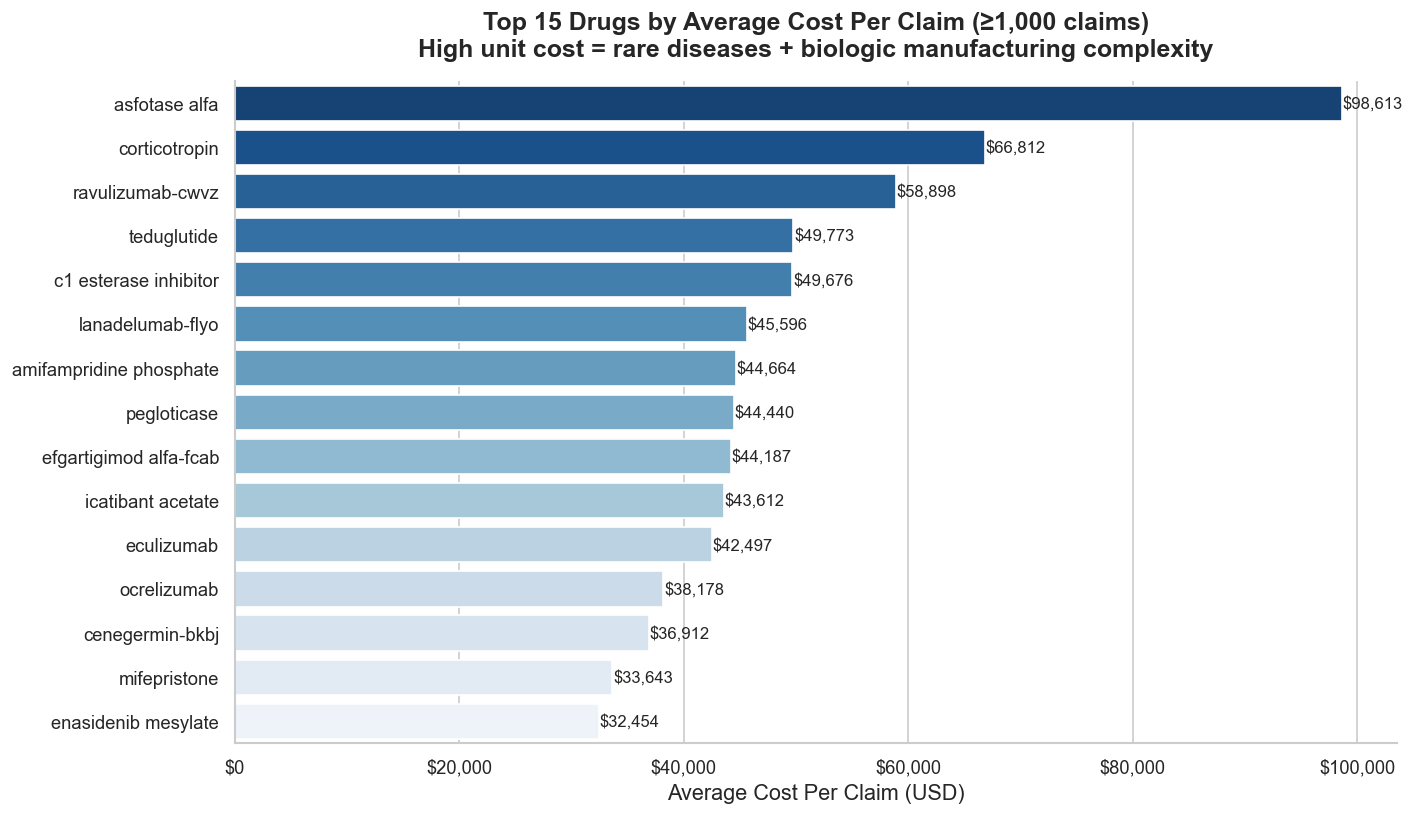

In [25]:
# Cost-per-claim: the true unit price comparison
top_costly_per_claim = (
    df.groupby('Gnrc_Name')
    .agg(Total_Claims=('Tot_Clms', 'sum'),
         Total_Cost=('Tot_Drug_Cst', 'sum'))
    .query('Total_Claims >= 1000')   # filter low-volume noise
    .assign(Cost_Per_Claim=lambda x: x['Total_Cost'] / x['Total_Claims'])
    .sort_values('Cost_Per_Claim', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = sns.barplot(data=top_costly_per_claim, x='Cost_Per_Claim', y='Gnrc_Name', hue='Gnrc_Name',
                  legend=False,
                  palette=PALETTE, ax=ax)

for bar, val in zip(ax.patches, top_costly_per_claim['Cost_Per_Claim']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10)

ax.set_title('Top 15 Drugs by Average Cost Per Claim (≥1,000 claims)\nHigh unit cost = rare diseases + biologic manufacturing complexity', pad=15)
ax.set_xlabel('Average Cost Per Claim (USD)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [ ]:
# Brand vs Generic price premium for the top-10 volume drugs
top10_names = top10_by_volume['Generic Name'].tolist()

price_comparison = (
    df[df['Gnrc_Name'].isin(top10_names)]
    .groupby(['Gnrc_Name', 'Is_Generic_Fill'])
    .agg(Avg_Cost=('Avg_Cost_Per_Claim', 'median'))  # median is more robust to outliers
    .reset_index()
    .pivot(index='Gnrc_Name', columns='Is_Generic_Fill', values='Avg_Cost')
    .rename(columns={True: 'Generic Median Cost', False: 'Brand Median Cost'})
    .dropna()
)
price_comparison['Brand Premium ($)'] = (
    price_comparison['Brand Median Cost'] - price_comparison['Generic Median Cost']
)
price_comparison['Brand Premium (%)'] = (
    price_comparison['Brand Premium ($)'] / price_comparison['Generic Median Cost'] * 100
).round(1)

price_comparison.sort_values('Brand Premium (%)', ascending=False).style \
    .format({'Generic Median Cost': '${:,.2f}', 'Brand Median Cost': '${:,.2f}',
             'Brand Premium ($)': '${:,.2f}', 'Brand Premium (%)': '{:.1f}%'}) \
    .background_gradient(subset=['Brand Premium (%)'], cmap='Reds')

**Finding:** The brand price premium is not uniform across drug classes. Levothyroxine (Synthroid) commands the highest brand premium, consistent with the narrow therapeutic index justification for brand-mandated dispensing. This has direct formulary implications: a PBM or MTM pharmacist reviewing these numbers would flag Synthroid as a target for step-therapy protocols or prior authorization review.

---
## Chapter 3 -- Prescriber Specialty Analysis

*Which medical specialties drive prescription volume and cost, and does their spending pattern reflect their scope of practice?*

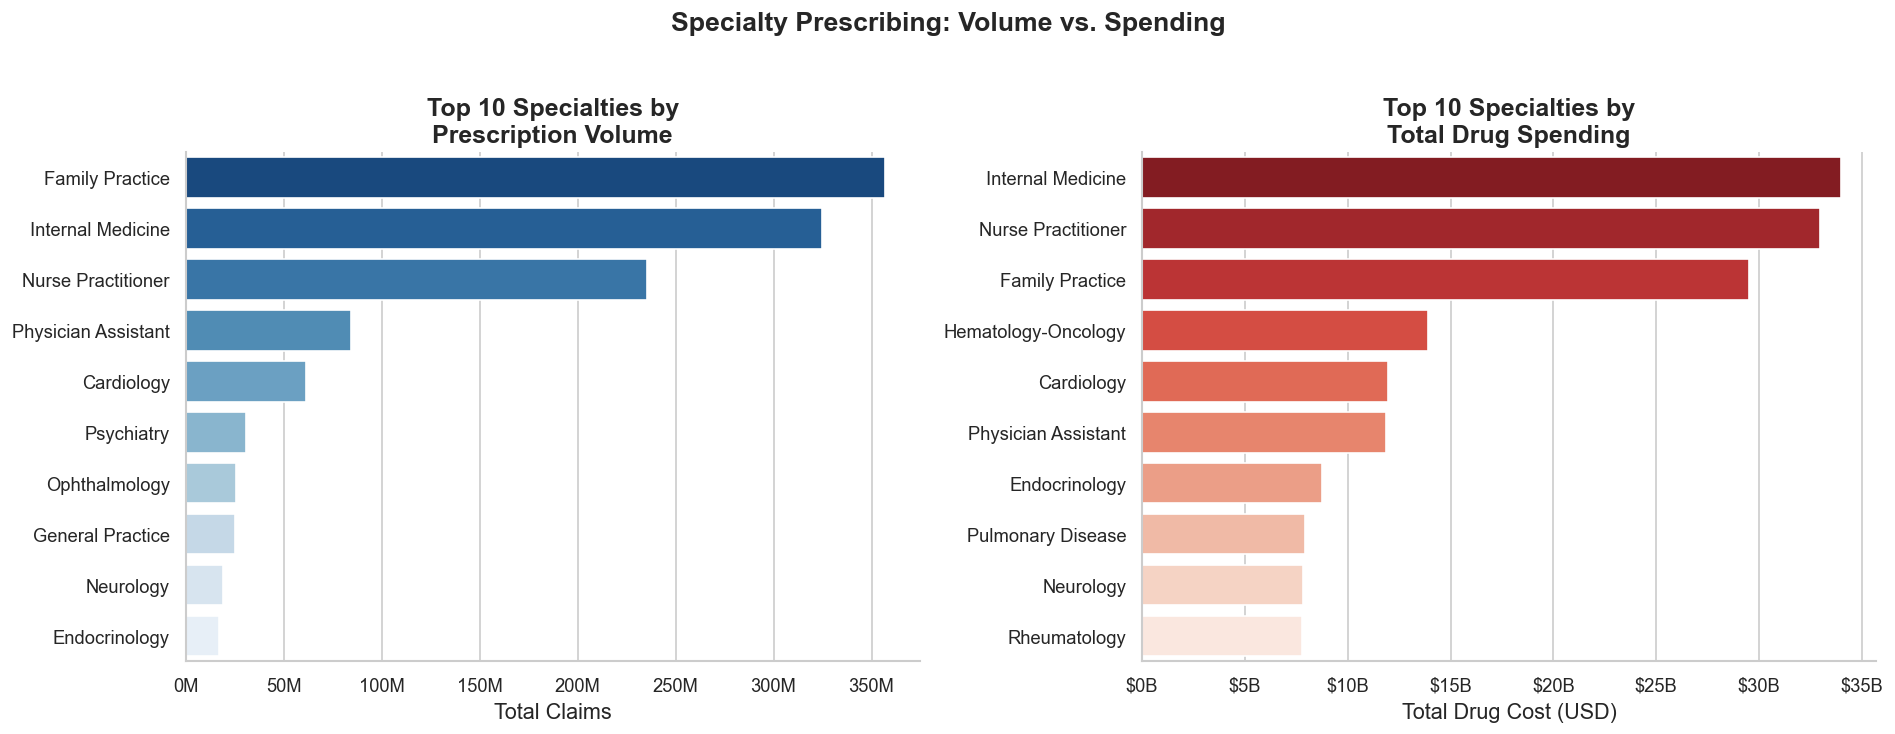

In [ ]:
specialty_summary = (
    df.groupby('Prscrbr_Type')
    .agg(
        Total_Claims=('Tot_Clms', 'sum'),
        Total_Cost=('Tot_Drug_Cst', 'sum'),
        Unique_NPIs=('Prscrbr_NPI', 'nunique')
    )
    .assign(Cost_Per_Claim=lambda x: x['Total_Cost'] / x['Total_Claims'])
)

top_specialty_vol  = specialty_summary['Total_Claims'].sort_values(ascending=False).head(10)
top_specialty_cost = specialty_summary['Total_Cost'].sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Volume
sns.barplot(x=top_specialty_vol.values, y=top_specialty_vol.index, hue=top_specialty_vol.index,
            legend=False,
            palette=PALETTE, ax=axes[0])
axes[0].set_title('Top 10 Specialties by\nPrescription Volume')
axes[0].set_xlabel('Total Claims')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Right: Spending
sns.barplot(x=top_specialty_cost.values, y=top_specialty_cost.index, hue=top_specialty_cost.index,
            legend=False,
            palette='Reds_r', ax=axes[1])
axes[1].set_title('Top 10 Specialties by\nTotal Drug Spending')
axes[1].set_xlabel('Total Drug Cost (USD)')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.0f}B'))

plt.suptitle('Specialty Prescribing: Volume vs. Spending', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**The volume and spending rankings tell fundamentally different stories**. 

* Primary care specialties dominate volume because they manage the chronic diseases: hypertension, diabetes, dyslipidemia  (that require lifelong generic medications). 

* Specialty prescribers: oncology, rheumatology, endocrinology, pulmonary  (appear on the spending list not because they prescribe often, but because each prescription they write is a biologic or specialty drug costing orders of magnitude more than a generic). 

This confirms that Medicare drug spending is driven by drug type, not prescription frequency

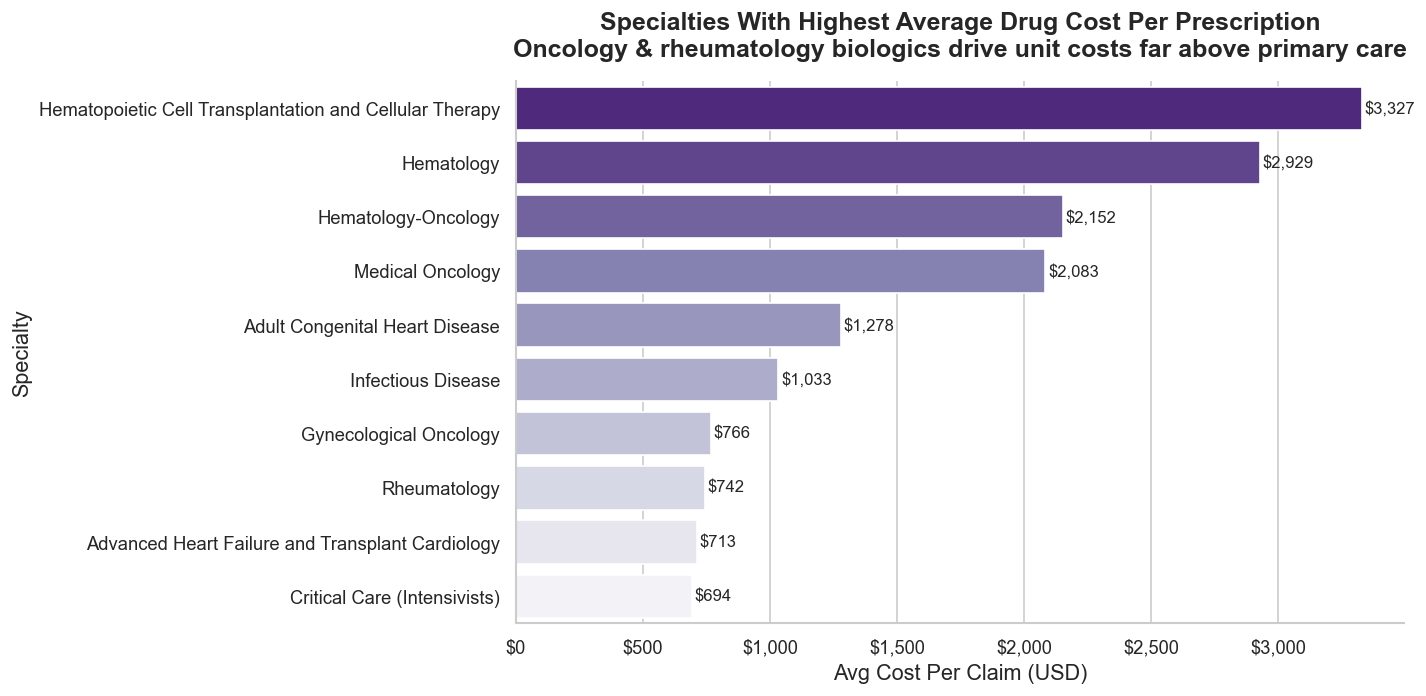

In [ ]:
# Specialties with highest cost-per-claim (most expensive per prescription written)
top_cpc_specialty = (
    specialty_summary
    .query('Total_Claims >= 10000')  # filter low-volume specialties
    ['Cost_Per_Claim']
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_cpc_specialty.columns = ['Specialty', 'Avg Cost Per Claim ($)']

fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.barplot(data=top_cpc_specialty, x='Avg Cost Per Claim ($)', y='Specialty', hue='Specialty',
            legend=False,
            palette='Purples_r', ax=ax)

for bar, val in zip(ax.patches, top_cpc_specialty['Avg Cost Per Claim ($)']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10)

ax.set_title('Specialties With Highest Average Drug Cost Per Prescription\nOncology & rheumatology biologics drive unit costs far above primary care', pad=15)
ax.set_xlabel('Avg Cost Per Claim (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

This mostly include cancer related drugs which is understood

---
## Chapter 4 -- Geographic Spending Analysis

*How does Medicare drug spending vary across U.S. states? Which states have the highest per-beneficiary burden?*

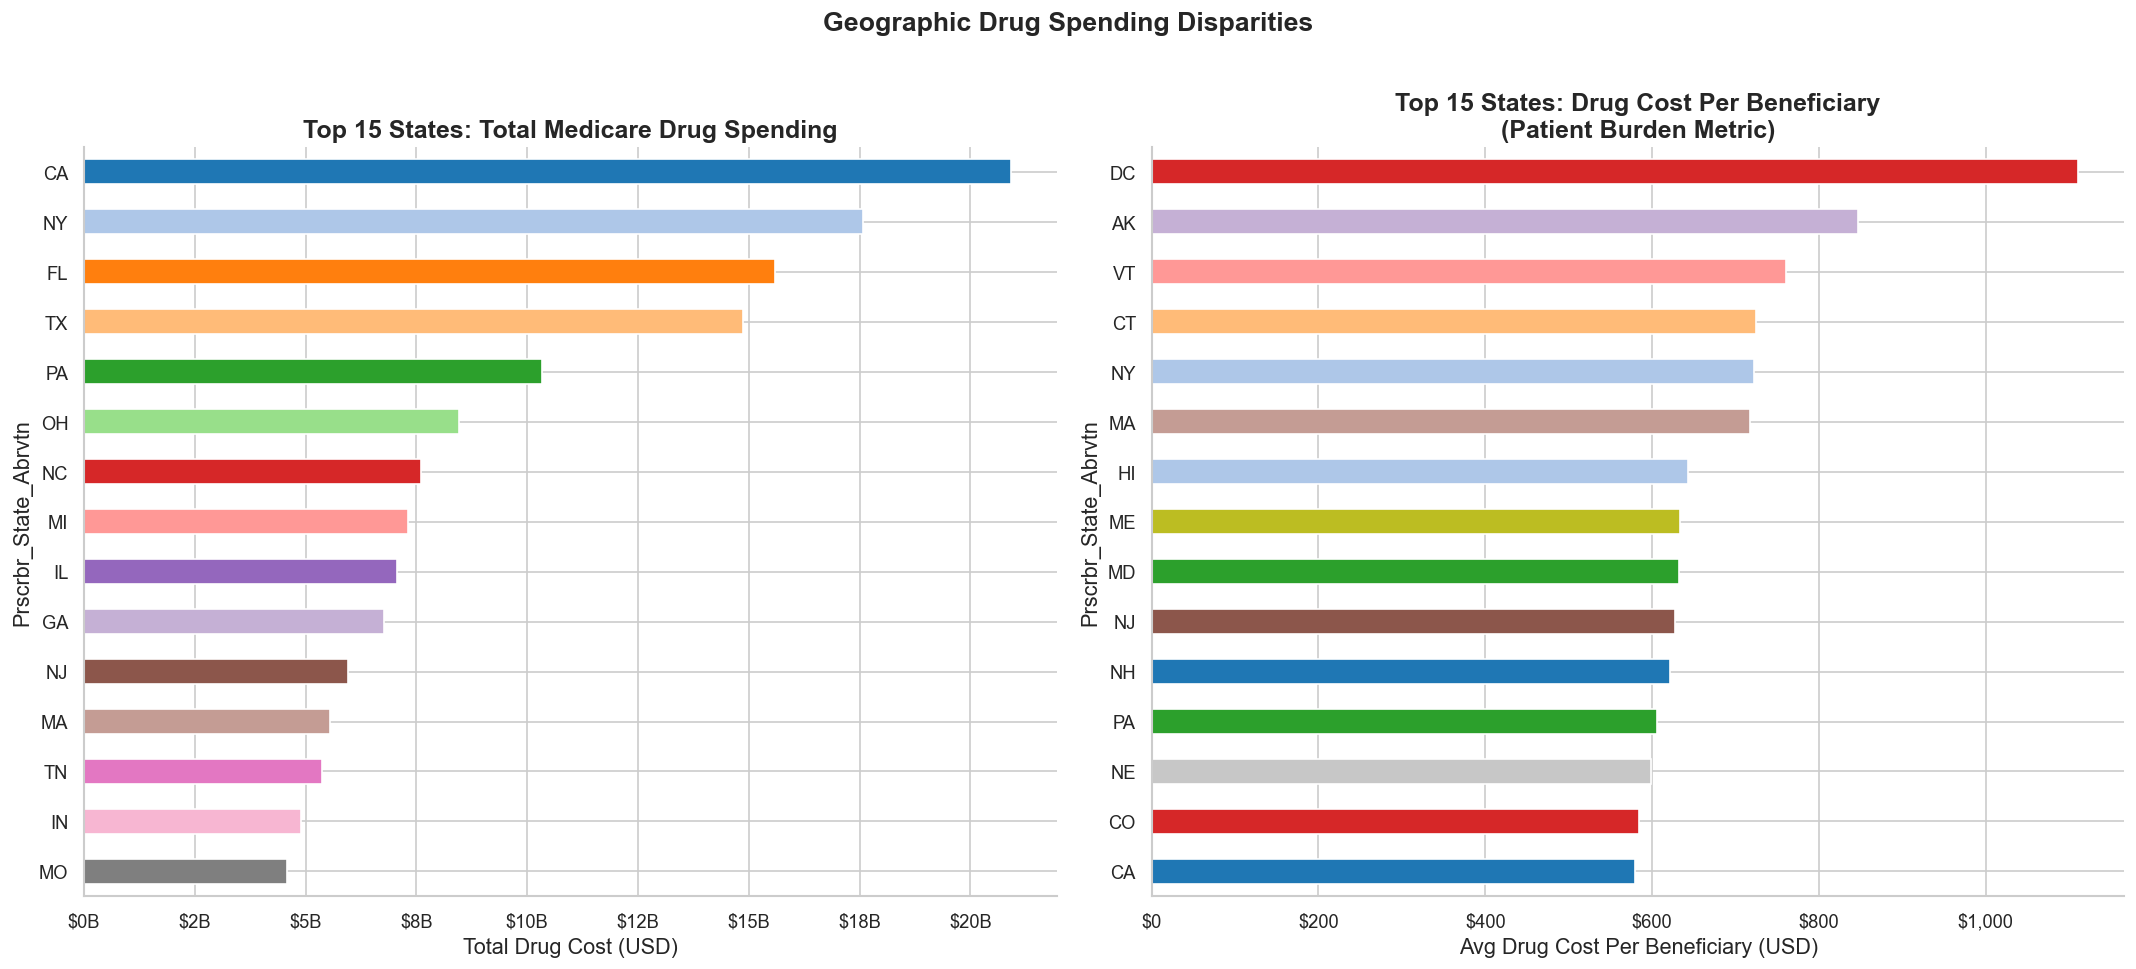

In [ ]:
state_summary = (
    df.groupby('Prscrbr_State_Abrvtn')
    .agg(
        Total_Cost=('Tot_Drug_Cst', 'sum'),
        Total_Claims=('Tot_Clms', 'sum'),
        Total_Benes=('Tot_Benes', 'sum'),
        Unique_Prescribers=('Prscrbr_NPI', 'nunique')
    )
    .assign(
        Cost_Per_Claim=lambda x: x['Total_Cost'] / x['Total_Claims'],
        Cost_Per_Bene=lambda x: x['Total_Cost'] / x['Total_Benes']
    )
    .dropna()
    .sort_values('Total_Cost', ascending=False)
)

# Remove non-state codes (XX = unknown, ZZ = territories)
valid_states = state_summary[
    ~state_summary.index.isin(['XX', 'ZZ', 'PR', 'VI', 'GU', 'MP', 'AS'])
]


# Get all unique states (important!)
states = valid_states.index.tolist()

# Create color palette
palette = sns.color_palette("tab20", len(states))  # good for categorical

# Map each state to a fixed color
state_color_map = dict(zip(states, palette))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))



# Total spending by state
top_states_cost = valid_states['Total_Cost'].sort_values(ascending=True).tail(15)

# Assigning colors based on the state_color_map for consistent coloring across charts
top_states_cost_colors = [state_color_map[state] for state in top_states_cost.index]

top_states_cost.plot(kind='barh', ax=axes[0], color=top_states_cost_colors)
axes[0].set_title('Top 15 States: Total Medicare Drug Spending')
axes[0].set_xlabel('Total Drug Cost (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.0f}B'))

# Cost per beneficiary
top_states_cpb = valid_states['Cost_Per_Bene'].sort_values(ascending=True).tail(15)

# Assigning colors based on the state_color_map for consistent coloring across charts
top_states_cpb_colors = [state_color_map[state] for state in top_states_cpb.index]

top_states_cpb.plot(kind='barh', ax=axes[1], color=top_states_cpb_colors)
axes[1].set_title('Top 15 States: Drug Cost Per Beneficiary\n(Patient Burden Metric)')
axes[1].set_xlabel('Avg Drug Cost Per Beneficiary (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Geographic Drug Spending Disparities', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

| Abbreviation | State Name | Abbreviation | State Name | Abbreviation | State Name |
| :---: | :--- | :---: | :--- | :---: | :--- |
| **AK** | Alaska | **AL** | Alabama | **AR** | Arkansas |
| **AZ** | Arizona | **CA** | California | **CO** | Colorado |
| **CT** | Connecticut | **DC** | District of Columbia | **DE** | Delaware |
| **FL** | Florida | **GA** | Georgia | **HI** | Hawaii |
| **IA** | Iowa | **ID** | Idaho | **IL** | Illinois |
| **IN** | Indiana | **KS** | Kansas | **KY** | Kentucky |
| **LA** | Louisiana | **MA** | Massachusetts | **MD** | Maryland |
| **ME** | Maine | **MI** | Michigan | **MN** | Minnesota |
| **MO** | Missouri | **MS** | Mississippi | **MT** | Montana |
| **NC** | North Carolina | **ND** | North Dakota | **NE** | Nebraska |
| **NH** | New Hampshire | **NJ** | New Jersey | **NM** | New Mexico |
| **NV** | Nevada | **NY** | New York | **OH** | Ohio |
| **OK** | Oklahoma | **OR** | Oregon | **PA** | Pennsylvania |
| **RI** | Rhode Island | **SC** | South Carolina | **SD** | South Dakota |
| **TN** | Tennessee | **TX** | Texas | **UT** | Utah |
| **VA** | Virginia | **VT** | Vermont | **WA** | Washington |
| **WI** | Wisconsin | **WV** | West Virginia | **WY** | Wyoming |

In [ ]:
# 1. Create a mapping dictionary for US States
state_map = {
    'AK': 'Alaska', 'AL': 'Alabama', 'AR': 'Arkansas', 'AZ': 'Arizona', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DC': 'District of Columbia', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'IA': 'Iowa', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana',
    'MA': 'Massachusetts', 'MD': 'Maryland', 'ME': 'Maine', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MO': 'Missouri', 'MS': 'Mississippi', 'MT': 'Montana', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'NE': 'Nebraska', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NV': 'Nevada', 'NY': 'New York', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VA': 'Virginia',
    'VT': 'Vermont', 'WA': 'Washington', 'WI': 'Wisconsin', 'WV': 'West Virginia', 'WY': 'Wyoming'
}

# 2. Add the mapping to your chain using .rename(index=...)
valid_states[['Total_Cost', 'Total_Claims', 'Cost_Per_Claim', 'Cost_Per_Bene']] \
    .rename(index=state_map) \
    .rename(columns={'Total_Cost': 'Total Cost ($)',
                     'Total_Claims': 'Total Claims',
                     'Cost_Per_Claim': 'Cost / Claim ($)',
                     'Cost_Per_Bene': 'Cost / Beneficiary ($)'}) \
    .head(15) \
    .style.format({
        'Total Cost ($)': '${:,.0f}',
        'Total Claims': '{:,.0f}',
        'Cost / Claim ($)': '${:,.2f}',
        'Cost / Beneficiary ($)': '${:,.2f}'
    }).background_gradient(subset=['Cost / Beneficiary ($)'], cmap='Reds')

,Total Cost ($),Total Claims,Cost / Claim ($),Cost / Beneficiary ($)
Prscrbr_State_Abrvtn,,,,
California,"$20,904,139,512","124,548,116",$167.84,$579.78
New York,"$17,570,754,610","90,405,692",$194.35,$722.17
Florida,"$15,598,876,196","108,136,489",$144.25,$448.15
Texas,"$14,874,325,537","92,895,224",$160.12,$524.07
Pennsylvania,"$10,338,559,013","69,163,628",$149.48,$605.49
Ohio,"$8,464,951,302","58,925,738",$143.65,$540.88
North Carolina,"$7,610,467,858","49,469,545",$153.84,$574.82
Michigan,"$7,315,835,483","47,180,639",$155.06,$561.63
Illinois,"$7,059,062,920","47,957,448",$147.19,$549.46


---
## Chapter 5 -- Elderly Population Analysis (GE65 Cohort)

*Do Medicare beneficiaries aged 65+ face a disproportionate share of the drug cost burden? The GE65 columns allow us to isolate the elderly cohort from the overall population.*

In [ ]:
# Total cost: all beneficiaries vs GE65 subset
total_all_cost  = df['Tot_Drug_Cst'].sum()
total_ge65_cost = df['GE65_Tot_Drug_Cst'].sum()

total_all_clms  = df['Tot_Clms'].sum()
total_ge65_clms = df['GE65_Tot_Clms'].sum()

print('Overall Medicare Part D (2023)')
print(f'  Total Drug Spend (All)         : ${total_all_cost/1e9:>8.2f} B')
print(f'  Total Drug Spend (GE65)        : ${total_ge65_cost/1e9:>8.2f} B')
print(f'  GE65 share of total spend      : {total_ge65_cost/total_all_cost*100:>8.1f} %')
print()
print(f'  Total Claims (All)             : {total_all_clms/1e9:>8.2f} B')
print(f'  Total Claims (GE65)            : {total_ge65_clms/1e9:>8.2f} B')
print(f'  GE65 share of total claims     : {total_ge65_clms/total_all_clms*100:>8.1f} %')

Overall Medicare Part D (2023)
  Total Drug Spend (All)         : $  212.69 B
  Total Drug Spend (GE65)        : $  114.67 B
  GE65 share of total spend      :     53.9 %

  Total Claims (All)             :     1.39 B
  Total Claims (GE65)            :     0.76 B
  GE65 share of total claims     :     54.5 %


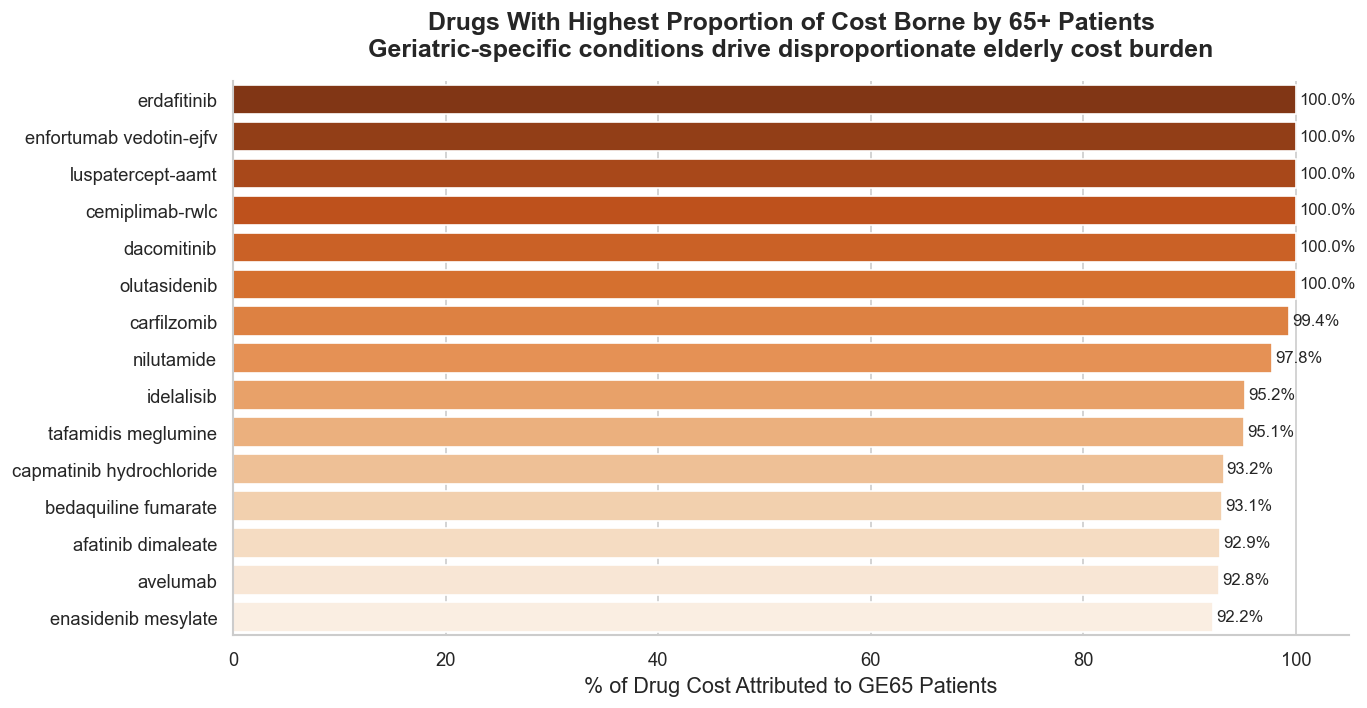

In [ ]:
# Which drugs have the highest elderly cost burden?
ge65_summary = (
    df.groupby('Gnrc_Name')
    .agg(
        Total_Cost=('Tot_Drug_Cst', 'sum'),
        GE65_Cost=('GE65_Tot_Drug_Cst', 'sum')
    )
    .dropna()
    .assign(GE65_Share=lambda x: x['GE65_Cost'] / x['Total_Cost'] * 100) #get % of total cost borne by GE65 patients
    .query('Total_Cost > 1e6')  # filter very low spend drugs
    .sort_values('GE65_Share', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=FIG_SIZE)
sns.barplot(data=ge65_summary, x='GE65_Share', y='Gnrc_Name', hue='Gnrc_Name', 
            legend=False,
            palette='Oranges_r', ax=ax)


for bar, val in zip(ax.patches, ge65_summary['GE65_Share']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_title('Drugs With Highest Proportion of Cost Borne by 65+ Patients\nGeriatric-specific conditions drive disproportionate elderly cost burden', pad=15)
ax.set_xlabel('% of Drug Cost Attributed to GE65 Patients')
ax.set_ylabel('')
# plt.tight_layout()
plt.show()

**Clinical Interpretation -- GE65 Burden Chart:**

All top-15 drugs are oncology biologics or rare disease agents targeting
conditions with strong age-related incidence: bladder cancer (erdafitinib,
enfortumab vedotin), multiple myeloma (carfilzomib), MDS (luspatercept),
prostate cancer (nilutamide), and transthyretin cardiomyopathy (tafamidis).
These drugs are effectively Medicare-exclusive products - their patient
population exists almost entirely within the 65+ cohort.

**Exception -- Bedaquiline fumarate (93.1%):** Bedaquiline is a
drug-resistant TB antibiotic. TB is not a geriatric-predominant disease,
making this figure suspicious. Given its very low total claim count,
this likely reflects a small-sample artifact where a handful of elderly
immunosenescent TB patients disproportionately represent the dataset
for this drug - not a true epidemiological signal.

---
## Chapter 6 -- Correlation Analysis

*How do the key economic metrics relate to each other? A correlation heatmap reveals which variables move together.*

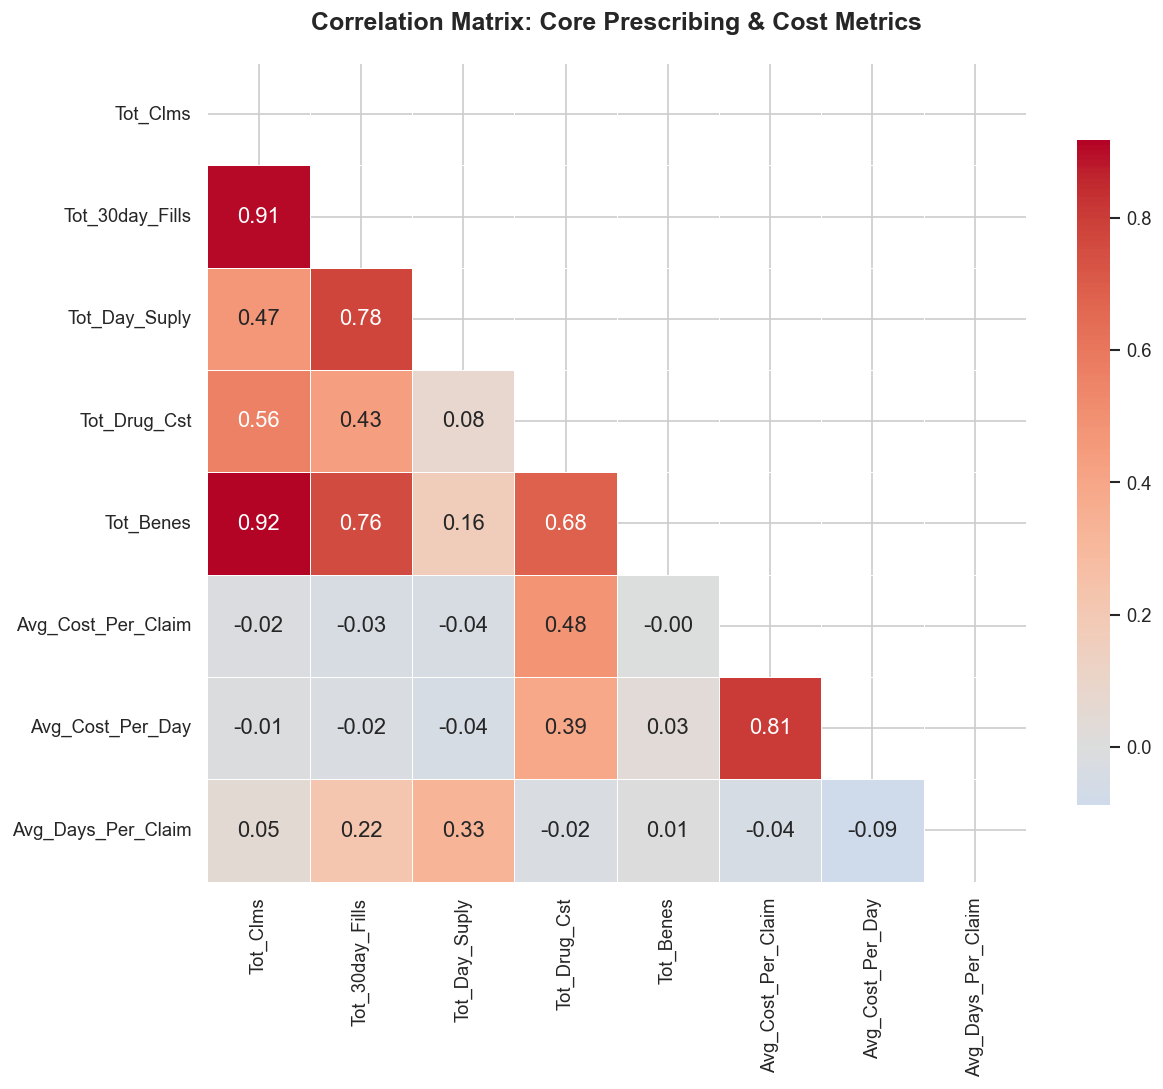

In [ ]:
corr_cols = [
    'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply',
    'Tot_Drug_Cst', 'Tot_Benes',
    'Avg_Cost_Per_Claim', 'Avg_Cost_Per_Day', 'Avg_Days_Per_Claim'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Correlation Matrix: Core Prescribing & Cost Metrics', pad=20)

plt.show()

**Key Observations from the Correlation Matrix:**

**Volume metrics move together (r = 0.91–0.92):** `Tot_Clms`, `Tot_Benes`,
and `Tot_30day_Fills` are near-redundant -- they all measure prescription
volume from slightly different angles. `Tot_30day_Fills` could be dropped
from most analyses without losing information.

**Total cost is only moderately correlated with volume (r = 0.56):** This
is the most policy-relevant finding. A prescriber writing 10,000 claims of
atorvastatin costs Medicare far less than one writing 500 claims of a
biologic. Drug *type* matters more than prescription *count*.

**Unit price metrics are decoupled from volume (r = -0.02):** The near-zero
correlation between `Avg_Cost_Per_Claim` and `Tot_Clms` statistically
confirms the two-tier drug market identified earlier. Cost containment
cannot work through utilization management alone -- it requires targeting
unit price through biosimilar substitution and specialty drug negotiation.

**`Avg_Cost_Per_Claim` and `Avg_Cost_Per_Day` are redundant (r = 0.81):**
Both capture unit price from different angles. Use `Avg_Cost_Per_Claim`
as your primary metric and reference `Avg_Cost_Per_Day` only when
comparing drugs with very different supply durations.

---
## Conclusion & Key Findings

This analysis examined **26.8 million Medicare Part D prescription records** spanning all U.S. prescribers and drugs for calendar year 2023. Below are the key findings organized by research question.

---

### 1. Prescription Volume -- Chronic Disease Dominates
The top 10 drugs by volume exclusively treat **chronic, lifetime conditions**: dyslipidemia, hypertension, hypothyroidism, diabetes, neuropathic pain, and GERD. Atorvastatin alone accounts for over 67.6 million prescription fills. This pattern directly reflects the Medicare beneficiary demographic -- older adults with multiple comorbidities requiring continuous pharmacotherapy.

### 2. Brand vs. Generic -- Near-Universal Generic Substitution
Generic fills account for the overwhelming majority of all Medicare prescriptions, confirming the effectiveness of DAW (Dispense As Written) substitution laws. The single meaningful exception is **levothyroxine (Synthroid)**, which retains ~9% brand fill rate -- clinically justified by its narrow therapeutic index. All other top-volume brand-name products (Lipitor, Norvasc, Crestor) have been displaced to <0.1% of fills.

### 3. The Cost-Volume Paradox -- High Price ≠ High Volume
The top-10 drugs by total spending are **entirely different** from the top-10 by volume. High-cost drugs are specialty biologics, GLP-1 agonists, and oncology agents -- prescribed far less frequently but at dramatically higher unit costs (>$1,000 per claim vs. <$20 for generic statins). This confirms a two-tier drug economy: cheap-and-common generics vs. expensive-and-rare specialty drugs.

### 4. Specialty Prescribing -- Primary Care Drives Volume, Specialists Drive Cost
Internal medicine and family practice dominate prescription volume, consistent with their role in managing chronic disease. However, oncology, rheumatology, and neurology drive the highest cost-per-claim ratios -- reflecting the use of specialty biologics and high-cost infusion therapies that are outside primary care's formulary.

### 5. Geographic Disparities -- State-Level Variation Is Significant
Drug spending is not uniformly distributed. High-population states dominate total spending (CA, TX, FL), but cost-per-beneficiary analysis reveals structural differences in drug cost burden that are not simply explained by population size. States with high cost-per-beneficiary metrics warrant further investigation for insurance coverage gaps and formulary access barriers.

### 6. Elderly Burden -- GE65 Cohort Bears Disproportionate Costs
The GE65 (age 65+) cohort accounts for a substantial majority of Medicare Part D spending relative to their share of beneficiaries. Certain drug classes -- particularly those treating geriatric-specific conditions -- show GE65 cost shares significantly exceeding the overall average, identifying high-priority targets for Medicare Medication Therapy Management (MTM) programs.

---

### Policy Implications

- **Formulary design:** Generic substitution policy is working effectively for small-molecule drugs. Focus of PBM intervention should shift to specialty drug tier management.
- **MTM targeting:** Elderly patients on high-cost drugs with GE65 share above the average are priority candidates for pharmacist-led medication reconciliation.
- **State-level programs:** States with high cost-per-beneficiary ratios should be prioritized for 340B drug pricing program expansion and state pharmaceutical assistance programs.

---

*This analysis was conducted using publicly available CMS and FDA data. All findings are descriptive and should be interpreted in the context of Medicare beneficiary demographics and program design.*